# Silicon Solar Cell Device Simulation

### MICS3090 (L01) · Integrated Circuit Devices

This tutorial uses **DEVSIM** and a one-dimensional **p⁺-on-n silicon solar cell** to connect device physics, numerical solution, experimental-data processing, and parameter calibration. It is designed for second-year undergraduate students: the emphasis is on building an interpretable workflow, not reproducing the full complexity of industrial TCAD.

> **Learning pathway:** Structure and equations → Newton iteration → Internal physical quantities → J–V and EQE → Sensitivity → Data processing → Parameter calibration → Identifiability


## 1. Learning Objectives and Notebook Workflow

After completing this notebook, you should be able to:

1. Describe the p⁺ emitter, n-type base, direction of illumination, and current-sign convention;
2. Relate the Poisson equation and carrier-continuity equations to Newton iteration;
3. Inspect doping, electrostatic potential, electric field, carrier concentrations, and optical generation rate in a DEVSIM solution;
4. Extract $J_{sc}$, $V_{oc}$, fill factor (FF), and maximum power density from a J–V curve;
5. Distinguish raw I–V data, processed J–V data, synthetic data, and historical experimental data;
6. Perform a joint calibration using Cell #3 illuminated and dark J–V data, illuminated $J_{sc}$, and illuminated $V_{oc}$, and then assess parameter identifiability.

Run all cells in order first. Then modify a small number of parameters in `config.py` for comparison experiments. Every figure in this notebook is generated by the current code and does not depend on pre-rendered screenshots.


## 2. Environment and Project Entry Points

The setup cell below automatically locates the project root. The main entry points are intentionally few: `config.py` stores the teaching baseline, `model/` implements the forward model, `calibration/` handles fitting and diagnostics, and `data/raw/` and `data/processed/` store instrument exports and standardized data, respectively.


In [1]:
import os
import sys
from pathlib import Path

start = Path.cwd().resolve()
project_root = next(
    (path for path in (start, *start.parents) if (path / "config.py").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from inside the project directory.")

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from config import CALIBRATION, MODEL_PARAMS, MODELED_INPUT_POWER_W_CM2
from model import check_params, profiles, run_simulation, simulate_eqe, terminal_iv
from model.analysis import band_edges, solar_metrics
from model.style import C_BLUE, C_DARK, C_GRAY, C_GREEN, C_ORANGE, apply_classroom_style

apply_classroom_style()
print("Project root detected.")
print("Notebook environment is ready.")


Project root detected.
Notebook environment is ready.


## 3. p⁺-on-n Structure and Coordinate Convention

Light enters through the front surface at $x=0$. It first passes through the thin, heavily doped **p⁺ emitter** and then enters the thicker, more lightly doped **n-type base**. Therefore, this project models neither an n-on-p device nor a device with the p-type region at the rear.

| Quantity | Convention used in this project |
|---|---|
| Position | Front surface: $x=0$; rear surface: $x=W$ |
| Doping | p⁺ emitter: $N_A>N_D$; n-type base: $N_D>N_A$ |
| Net doping | $N_D-N_A<0$ (p⁺ emitter); $N_D-N_A>0$ (n-type base) |
| J–V current | The power-generating direction is positive; therefore, $J_{sc}>0$ at short circuit |
| Forward voltage | Lowers the junction barrier, allowing the diode dark current to oppose the photocurrent |

“p⁺-on-n” describes the device layer sequence, whereas “generation-positive” describes the current-sign convention used for plotting and calibration. These are separate concepts.


## 4. Governing Equations, Sign Conventions, and Model Scope

DEVSIM simultaneously solves for the electrostatic potential $\psi$, electron concentration $n$, and hole concentration $p$:

$$
\frac{d^2\psi}{dx^2}=-\frac{q}{\varepsilon_{Si}}
\left(p-n+N_D^+-N_A^-\right),
$$

$$
\frac{dJ_n}{dx}=q(R-G),\qquad
\frac{dJ_p}{dx}=-q(R-G),
$$

together with the drift–diffusion current relations. The generation rate $G(x)$ is obtained from multiwavelength Beer–Lambert absorption, while $R$ includes SRH and Auger bulk recombination. Front- and rear-surface recombination are approximated using finite-thickness effective “dead layers.”

This is a **teaching model**: it uses a one-dimensional abrupt junction, Boltzmann statistics, constant low-field mobilities, no band-gap narrowing, and 16 spectral sampling points. It omits lateral current flow and detailed contact physics. `photon_flux` is an **effective photogeneration scale factor**, not a calibrated “sun” value; it may be expressed in suns only after a mapping has been established using independently calibrated irradiance.


## 5. Newton Iteration: Why Does the Solver Need an Initial Guess?

The exponential dependence of $n(\psi)$ and $p(\psi)$ makes the Poisson equation nonlinear. Newton's method repeatedly linearizes $F(\psi)=0$ and updates the solution, while backtracking damping prevents an individual step from moving too far. The NumPy example below solves a simplified p⁺-on-n junction and compares the initial and converged band diagrams alongside the residual history. To keep this standalone NumPy demonstration short and stable, it uses lower illustrative doping values while preserving the same doping ratio; these are not the DEVSIM device values in `config.py`.


Newton converged in 12 states; built-in potential = 0.7156 V.


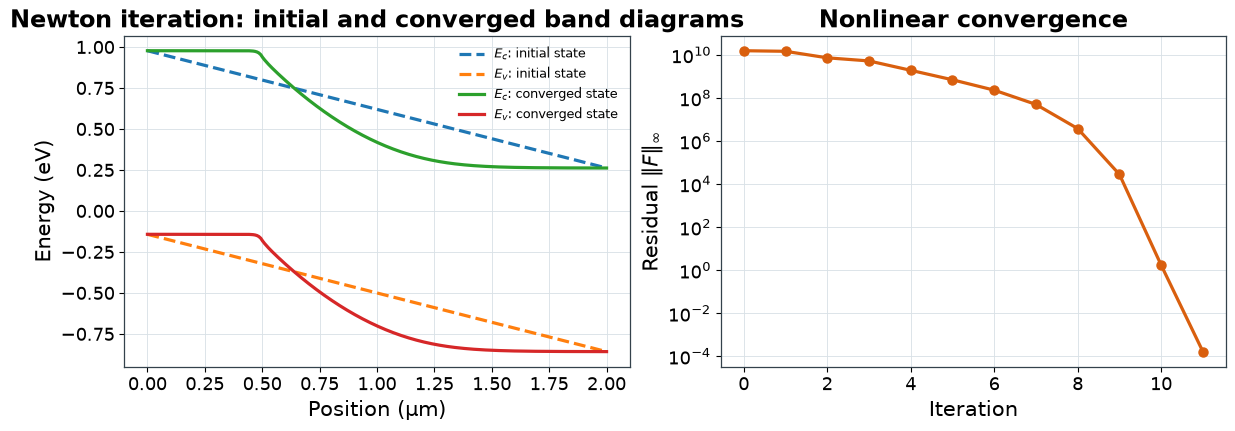

In [2]:
VT, NI = 0.0259, 1e10
q, eps0 = 1.602176634e-19, 8.854187817e-14
eps_si = 11.7 * eps0


def solve_tridiagonal(lower, diagonal, upper, right_hand_side):
    'Solve a tridiagonal linear system with the Thomas algorithm.'
    lower = lower.astype(float, copy=True)
    diagonal = diagonal.astype(float, copy=True)
    upper = upper.astype(float, copy=True)
    result = right_hand_side.astype(float, copy=True)
    for index in range(1, len(diagonal)):
        factor = lower[index - 1] / diagonal[index - 1]
        diagonal[index] -= factor * upper[index - 1]
        result[index] -= factor * result[index - 1]
    result[-1] /= diagonal[-1]
    for index in range(len(diagonal) - 2, -1, -1):
        result[index] = (result[index] - upper[index] * result[index + 1]) / diagonal[index]
    return result


def poisson_newton(x, net, psi_left, psi_right, max_iter=60, tol=1e-10):
    'Solve a 1D equilibrium Poisson problem with damped Newton iteration.'
    count, dx = len(x), x[1] - x[0]
    psi = psi_left + (psi_right - psi_left) * x / x[-1]
    history, residuals = [psi.copy()], []

    def equation(phi):
        electrons = NI * np.exp(phi / VT)
        holes = NI * np.exp(-phi / VT)
        charge_term = q / eps_si * (holes - electrons + net)
        value = np.zeros(count)
        value[1:-1] = (
            phi[:-2] - 2 * phi[1:-1] + phi[2:]
        ) / dx**2 + charge_term[1:-1]
        value[0], value[-1] = phi[0] - psi_left, phi[-1] - psi_right
        return value

    initial_residual = None
    if max_iter < 1:
        raise ValueError("max_iter must be at least 1")
    for _ in range(max_iter):
        value = equation(psi)
        residual = float(np.max(np.abs(value)))
        residuals.append(residual)
        initial_residual = residual if initial_residual is None else initial_residual
        if residual < tol * initial_residual:
            break

        electrons = NI * np.exp(psi / VT)
        holes = NI * np.exp(-psi / VT)
        derivative = -(q / (eps_si * VT)) * (electrons + holes)
        inverse_dx2 = 1 / dx**2
        diagonal = -2 * inverse_dx2 + derivative
        lower = np.full(count - 1, inverse_dx2)
        upper = np.full(count - 1, inverse_dx2)
        diagonal[0] = diagonal[-1] = 1.0
        upper[0] = lower[-1] = 0.0
        step = solve_tridiagonal(lower, diagonal, upper, -value)

        damping = 1.0
        while damping >= 1e-8:
            trial = np.clip(psi + damping * step, -15, 15)
            if float(np.max(np.abs(equation(trial)))) < residual:
                break
            damping *= 0.5
        psi = trial
        history.append(psi.copy())
    else:
        final_residual = float(np.max(np.abs(equation(psi))))
        residuals.append(final_residual)
        if final_residual >= tol * initial_residual:
            raise RuntimeError(
                f"Newton iteration did not converge in {max_iter} updates; "
                f"relative residual = {final_residual / initial_residual:.3e}"
            )
    return history, residuals


x_newton = np.linspace(0, 2e-4, 240)
net = np.where(x_newton < 0.5e-4, -1e17, 1e15)
psi_left = -VT * np.log(1e17 / NI)
psi_right = VT * np.log(1e15 / NI)
history, residuals = poisson_newton(x_newton, net, psi_left, psi_right)
built_in_voltage = history[-1][-1] - history[-1][0]
print(
    f"Newton converged in {len(history)} states; "
    f"built-in potential = {built_in_voltage:.4f} V."
)

band_gap = 1.12
fig, (ax_band, ax_residual) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for state, label, style in ((history[0], "initial state", "--"),
                            (history[-1], "converged state", "-")):
    ax_band.plot(x_newton * 1e4, -state + band_gap / 2, style, label=f"$E_c$: {label}")
    ax_band.plot(x_newton * 1e4, -state - band_gap / 2, style, label=f"$E_v$: {label}")
ax_band.set(xlabel="Position (µm)", ylabel="Energy (eV)",
            title="Newton iteration: initial and converged band diagrams")
ax_band.legend(frameon=False, fontsize=9)
ax_band.grid(True)

ax_residual.semilogy(range(len(residuals)), residuals, "o-", color=C_ORANGE)
ax_residual.set(xlabel="Iteration", ylabel=r"Residual $\|F\|_\infty$",
                title="Nonlinear convergence")
ax_residual.grid(True, which="both")
plt.show()


## 6. From Equations to an Executable Model

A single forward simulation proceeds through the following sequence:

`parameters → 1D mesh → equilibrium Poisson → dark drift–diffusion → illumination ramp → voltage sweep → terminal corrections → metrics`

Light enters through the p⁺ front surface. Electrons are collected primarily at the n-type side, while holes are collected primarily at the p⁺ side. Calibration changes only the effective parameters exposed by `config.py`; the physical model formulation remains fixed so that model–data discrepancies remain interpretable.


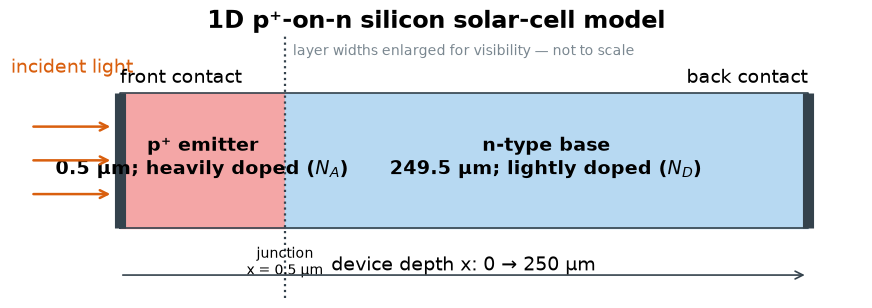

In [3]:
device_params = check_params({
    **MODEL_PARAMS, "series_resistance": 0.0, "shunt_resistance": 0.0
})  # internal profiles describe the intrinsic device
emitter_um = device_params.emitter_depth * 1e4
thickness_um = device_params.thickness * 1e4
display_junction = 0.24  # enlarged so the 0.5 µm emitter remains visible

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.fill_betweenx([0, 1], 0, display_junction, color="#f4a6a6")
ax.fill_betweenx([0, 1], display_junction, 1, color="#b7d9f2")
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color=C_DARK, lw=1.2)
ax.plot([0, 0], [0, 1], color=C_DARK, lw=8, solid_capstyle="butt")
ax.plot([1, 1], [0, 1], color=C_DARK, lw=8, solid_capstyle="butt")
ax.text(display_junction / 2, 0.52,
        f"p⁺ emitter\n{emitter_um:g} µm; heavily doped ($N_A$)",
        ha="center", va="center", weight="bold")
ax.text((display_junction + 1) / 2, 0.52,
        f"n-type base\n{thickness_um - emitter_um:g} µm; lightly doped ($N_D$)",
        ha="center", va="center", weight="bold")
ax.axvline(display_junction, color=C_DARK, ls=":", lw=1.6)
ax.text(display_junction, -0.13, f"junction\nx = {emitter_um:g} µm",
        ha="center", va="top", fontsize=10)
for ypos in (0.25, 0.50, 0.75):
    ax.annotate("", xy=(-0.01, ypos), xytext=(-0.13, ypos),
                arrowprops=dict(arrowstyle="->", color=C_ORANGE, lw=1.8))
ax.text(-0.07, 1.15, "incident light", color=C_ORANGE, ha="center")
ax.annotate("", xy=(1, -0.35), xytext=(0, -0.35),
            arrowprops=dict(arrowstyle="->", color=C_DARK, lw=1.2))
ax.text(0.50, -0.35, f"device depth x: 0 → {thickness_um:g} µm",
        ha="center", va="bottom")
ax.text(0, 1.04, "front contact", ha="left", va="bottom")
ax.text(1, 1.04, "back contact", ha="right", va="bottom")
ax.text(0.50, 1.28, "layer widths enlarged for visibility — not to scale",
        color=C_GRAY, ha="center", fontsize=10)
ax.set_xlim(-0.16, 1.08)
ax.set_ylim(-0.52, 1.42)
ax.set_title("1D p⁺-on-n silicon solar-cell model")
ax.axis("off")
plt.show()


## 7. Internal Physical Quantities at Short Circuit

Terminal J–V behavior tells us what the device does, while internal profiles help explain why. The figure below retains four complementary panels. The band diagram is shown separately in the following figure to avoid duplicate information.


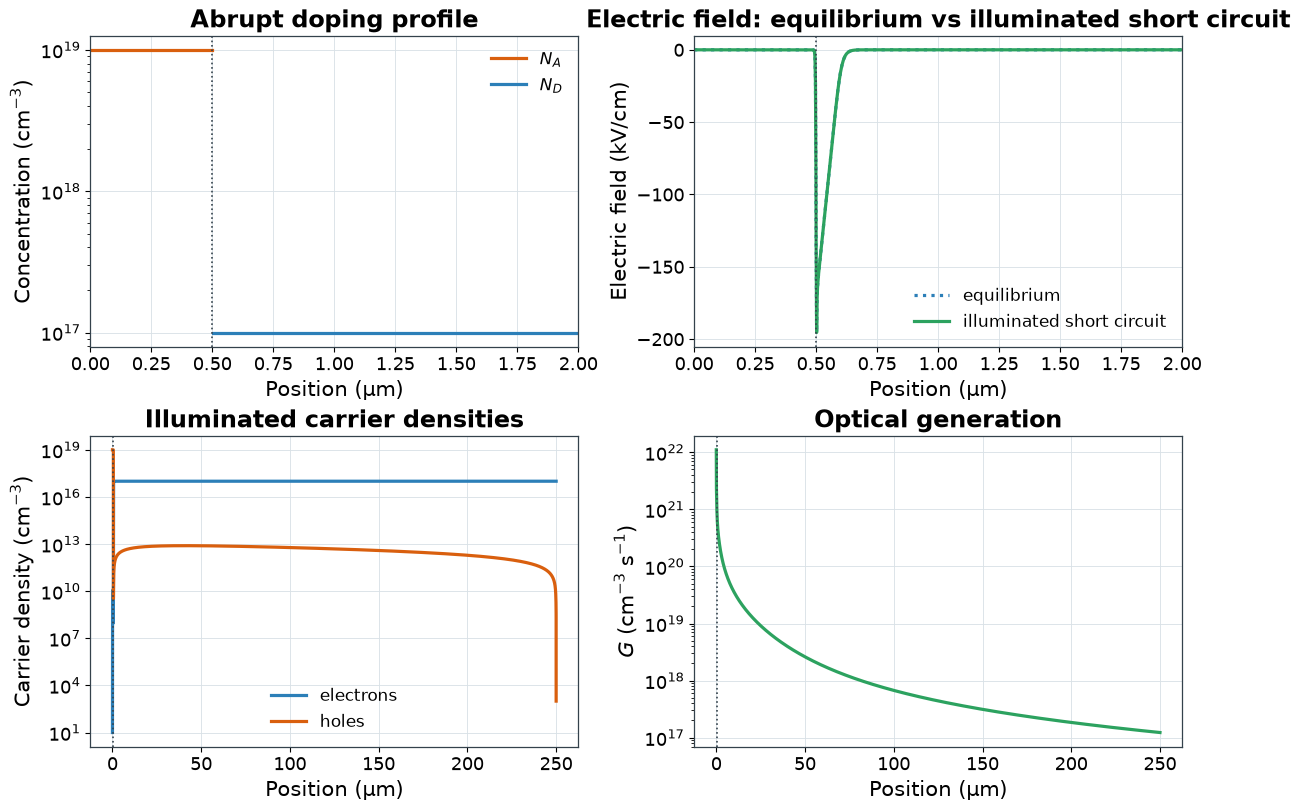

In [4]:
device_data = profiles(device_params, bias=0.0)
position_um = device_data["x"] * 1e4
junction_um = device_params.emitter_depth * 1e4
junction_zoom_um = 2.0
equilibrium_field = -np.gradient(device_data["potential"], device_data["x"])
short_circuit_field = -np.gradient(device_data["ill_potential"], device_data["x"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.semilogy(position_um, np.where(device_data["acceptors"] > 0, device_data["acceptors"], np.nan),
            color=C_ORANGE, label="$N_A$")
ax.semilogy(position_um, np.where(device_data["donors"] > 0, device_data["donors"], np.nan),
            color=C_BLUE, label="$N_D$")
ax.set(xlabel="Position (µm)", ylabel="Concentration (cm$^{-3}$)", title="Abrupt doping profile")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.plot(position_um, equilibrium_field / 1e3, color=C_BLUE, ls=":", label="equilibrium")
ax.plot(position_um, short_circuit_field / 1e3, color=C_GREEN, label="illuminated short circuit")
ax.set(xlabel="Position (µm)", ylabel="Electric field (kV/cm)",
       title="Electric field: equilibrium vs illuminated short circuit")
ax.legend(frameon=False)
for ax in axes[0, :]:
    ax.set_xlim(0, junction_zoom_um)

ax = axes[1, 0]
ax.semilogy(position_um, device_data["ill_electrons"], color=C_BLUE, label="electrons")
ax.semilogy(position_um, device_data["ill_holes"], color=C_ORANGE, label="holes")
ax.set(xlabel="Position (µm)", ylabel="Carrier density (cm$^{-3}$)", title="Illuminated carrier densities")
ax.legend(frameon=False)

ax = axes[1, 1]
ax.semilogy(position_um, np.maximum(device_data["generation"], 1e-30), color=C_GREEN)
ax.set(xlabel="Position (µm)", ylabel="$G$ (cm$^{-3}$ s$^{-1}$)", title="Optical generation")

for ax in axes.flat:
    ax.axvline(junction_um, color=C_DARK, ls=":", lw=1.2)
    ax.grid(True)
plt.show()


Built-in potential from the electrostatic solution: 0.9537 V


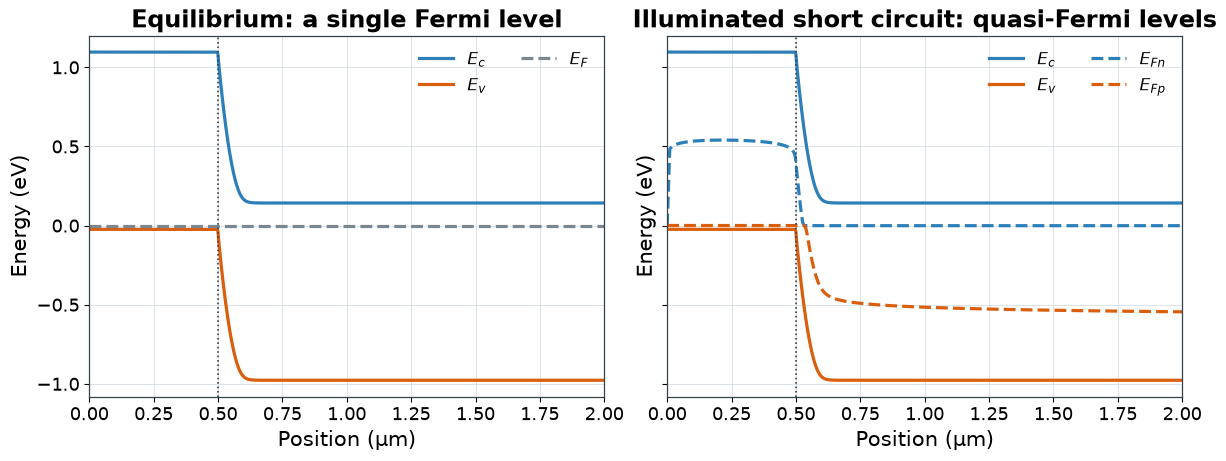

In [5]:
eq_bands = band_edges(
    device_data["potential"], device_data["electrons"], device_data["holes"],
    device_params.temperature,
)
lit_bands = band_edges(
    device_data["ill_potential"], device_data["ill_electrons"], device_data["ill_holes"],
    device_params.temperature,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True, sharey=True)
axes[0].plot(position_um, eq_bands[0], color=C_BLUE, label="$E_c$")
axes[0].plot(position_um, eq_bands[1], color=C_ORANGE, label="$E_v$")
axes[0].axhline(0, color=C_GRAY, ls="--", label="$E_F$")
axes[0].set_title("Equilibrium: a single Fermi level")

axes[1].plot(position_um, lit_bands[0], color=C_BLUE, label="$E_c$")
axes[1].plot(position_um, lit_bands[1], color=C_ORANGE, label="$E_v$")
axes[1].plot(position_um, lit_bands[2], "--", color=C_BLUE, label="$E_{Fn}$")
axes[1].plot(position_um, lit_bands[3], "--", color=C_ORANGE, label="$E_{Fp}$")
axes[1].set_title("Illuminated short circuit: quasi-Fermi levels")

for ax in axes:
    ax.axvline(junction_um, color=C_DARK, ls=":", lw=1.2)
    ax.set_xlim(0, junction_zoom_um)
    ax.set(xlabel="Position (µm)", ylabel="Energy (eV)")
    ax.legend(frameon=False, ncol=2)
    ax.grid(True)

left_index = int(np.argmin(np.abs(position_um - 0.1)))
right_index = int(np.argmin(np.abs(position_um - min(10.0, thickness_um - 1.0))))
built_in_voltage_model = (
    device_data["potential"][right_index] - device_data["potential"][left_index]
)
print(f"Built-in potential from the electrostatic solution: {built_in_voltage_model:.4f} V")
plt.show()


## 8. J–V Characteristics and Performance Metrics

Because the model uses current density $J$, its characteristic is called **J–V**. The raw Keithley files record total current $I$ and should therefore be described as **I–V** data. Under the generation-positive convention, $J(0)=J_{sc}>0$, the open-circuit point satisfies $J(V_{oc})=0$, and the power density in the power-generating quadrant is $P=VJ>0$. The 16 optical bins approximate the above-band-gap photons that drive photogeneration. When illustrative efficiency is reported, a total simulated input power of 100 mW/cm² is declared separately; this total includes spectral power outside the photogeneration bins.


Jsc  = 29.34 mA/cm^2
Voc  = 0.6147 V
FF   = 0.830
Pmax = 14.96 mW/cm^2
Illustrative modeled efficiency at 100 mW/cm^2 = 14.96%


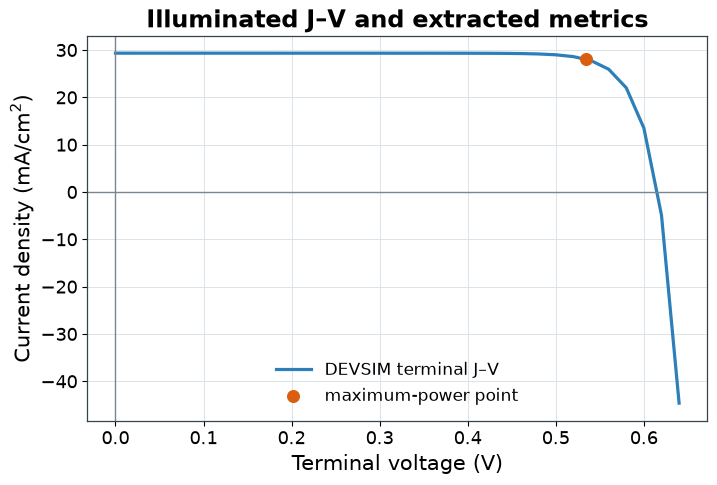

In [6]:
voltage, current_density = terminal_iv(MODEL_PARAMS)
modeled_pin = MODELED_INPUT_POWER_W_CM2 * device_params.photon_flux
metrics = solar_metrics(voltage, current_density, pin=modeled_pin)

print(f"Jsc  = {metrics['Jsc'] * 1e3:.2f} mA/cm^2")
print(f"Voc  = {metrics['Voc']:.4f} V")
print(f"FF   = {metrics['FF']:.3f}")
print(f"Pmax = {metrics['Pmax'] * 1e3:.2f} mW/cm^2")
print(f"Illustrative modeled efficiency at {modeled_pin * 1e3:.0f} mW/cm^2 = "
      f"{metrics['eta'] * 100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(voltage, current_density * 1e3, color=C_BLUE, label="DEVSIM terminal J–V")
ax.scatter(metrics["Vmp"], metrics["Jmp"] * 1e3, color=C_ORANGE, s=70,
           zorder=3, label="maximum-power point")
ax.axhline(0, color=C_GRAY, lw=1)
ax.axvline(0, color=C_GRAY, lw=1)
ax.set(xlabel="Terminal voltage (V)", ylabel="Current density (mA/cm$^2$)",
       title="Illuminated J–V and extracted metrics")
ax.grid(True)
ax.legend(frameon=False)
plt.show()


## 9. External Quantum Efficiency (EQE)

$$\mathrm{EQE}(\lambda)=\frac{\text{collected electrons per second}}{\text{incident photons per second at }\lambda}.$$

All curves below are generated by DEVSIM monochromatic short-circuit simulations and are compared with an absorption-only upper bound that assumes every absorbed photon is collected. **No experimental EQE measurements are included; all displayed EQE data are simulation results.** This course project **does not require additional measured EQE data**. If spectral responsivity is measured in the laboratory, it may be supplied as an independent CSV file for validation rather than incorporated into the default example.

The 16-bin AM1.5-like spectrum used here is a teaching approximation, not a metrological substitute for an ASTM reference spectrum.


EQE-integrated Jsc = 29.34 mA/cm^2
All-bin Jsc        = 29.34 mA/cm^2
Relative mismatch  = 0.00%


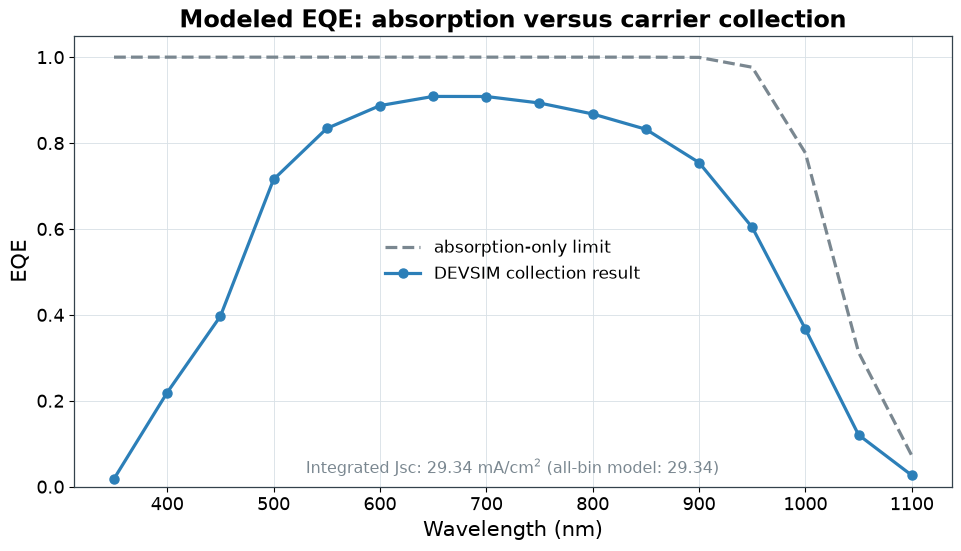

In [7]:
from model.spectrum import absorption_cm, bin_photon_flux, wavelengths_nm

wavelengths = wavelengths_nm()
absorption = absorption_cm()
eqe_params = check_params({**MODEL_PARAMS, "series_resistance": 0.0, "shunt_resistance": 0.0})
electron_charge = 1.602176634e-19

modeled_eqe = np.array([
    simulate_eqe(eqe_params, index)
    / (electron_charge * eqe_params.photon_flux * bin_photon_flux(index))
    for index in range(len(wavelengths))
])
absorption_limit = (
    (1 - eqe_params.front_reflectance)
    * (1 - np.exp(-absorption * eqe_params.thickness))
)

photon_bins = np.array([bin_photon_flux(index) for index in range(len(wavelengths))])
eqe_integrated_jsc = (
    electron_charge * eqe_params.photon_flux * np.sum(modeled_eqe * photon_bins)
)
_, all_bin_current = run_simulation(
    params=dict(vars(eqe_params)), voltages=np.array([0.0])
)
all_bin_jsc = float(all_bin_current[0])
print(f"EQE-integrated Jsc = {eqe_integrated_jsc * 1e3:.2f} mA/cm^2")
print(f"All-bin Jsc        = {all_bin_jsc * 1e3:.2f} mA/cm^2")
print(f"Relative mismatch  = {abs(eqe_integrated_jsc - all_bin_jsc) / abs(all_bin_jsc):.2%}")

fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
ax.plot(wavelengths, absorption_limit, "--", color=C_GRAY,
        label="absorption-only limit")
ax.plot(wavelengths, modeled_eqe, "o-", color=C_BLUE,
        label="DEVSIM collection result")
ax.set(xlabel="Wavelength (nm)", ylabel="EQE",
       title="Modeled EQE: absorption versus carrier collection")
ax.set_ylim(0, 1.05)
ax.grid(True)
ax.legend(frameon=False)
ax.text(0.5, 0.03,
        f"Integrated Jsc: {eqe_integrated_jsc * 1e3:.2f} mA/cm$^2$ "
        f"(all-bin model: {all_bin_jsc * 1e3:.2f})",
        transform=ax.transAxes, ha="center", color=C_GRAY, fontsize=11.5)
plt.show()


## 10. Sensitivity: Can a Parameter Change Be Detected in Terminal Data?

A parameter can be calibrated reliably only when the observables are sufficiently sensitive to it. The following example scans only the minority-carrier lifetime—the hole lifetime—in the n-type base to build intuition for the relationship between a parameter and the resulting J–V metrics. Lifetime, surface recombination, and optical loss can produce similar effects; therefore, sensitivity does not imply unique identifiability.


,Hole lifetime (s),$J_{sc}$ (mA/cm²),$V_{oc}$ (V)
0,1.00e-06,26.32,0.6052
1,3.16e-06,28.09,0.6106
2,1.00e-05,29.34,0.6147
3,3.16e-05,30.03,0.6170
4,1.00e-04,30.31,0.6181


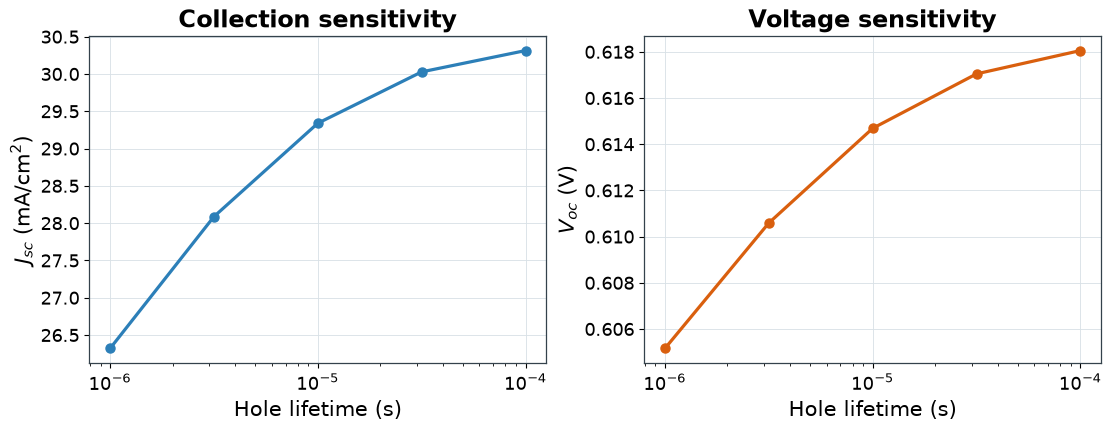

In [8]:
lifetimes = np.geomspace(1e-6, 1e-4, 5)
sensitivity_rows = []
for lifetime in lifetimes:
    sweep_params = {**MODEL_PARAMS, "hole_lifetime": float(lifetime)}
    sweep_voltage, sweep_current = terminal_iv(params=sweep_params)
    sweep_metrics = solar_metrics(sweep_voltage, sweep_current, pin=None)
    sensitivity_rows.append(
        (lifetime, sweep_metrics["Jsc"] * 1e3, sweep_metrics["Voc"])
    )

sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=["hole_lifetime_s", "Jsc_mA_cm2", "Voc_V"],
)
sensitivity_table = sensitivity.assign(
    hole_lifetime_s=lambda frame: frame["hole_lifetime_s"].map("{:.2e}".format),
    Jsc_mA_cm2=lambda frame: frame["Jsc_mA_cm2"].map("{:.2f}".format),
    Voc_V=lambda frame: frame["Voc_V"].map("{:.4f}".format),
)
display(sensitivity_table.rename(columns={
    "hole_lifetime_s": "Hole lifetime (s)",
    "Jsc_mA_cm2": "$J_{sc}$ (mA/cm²)",
    "Voc_V": "$V_{oc}$ (V)",
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].semilogx(sensitivity["hole_lifetime_s"], sensitivity["Jsc_mA_cm2"],
                 "o-", color=C_BLUE)
axes[0].set(xlabel="Hole lifetime (s)", ylabel="$J_{sc}$ (mA/cm$^2$)",
            title="Collection sensitivity")
axes[1].semilogx(sensitivity["hole_lifetime_s"], sensitivity["Voc_V"],
                 "o-", color=C_ORANGE)
axes[1].set(xlabel="Hole lifetime (s)", ylabel="$V_{oc}$ (V)",
            title="Voltage sensitivity")
for ax in axes:
    ax.grid(True)
plt.show()


## 11. Data Provenance: Raw, Processed, and Synthetic Data

- `data/raw/keithley/`: **Historical teaching-laboratory exports** from a Keithley 2636B. These files preserve the instrument format and metadata; they are not newly measured student data. Some raw files retain instrument labels generated under a Chinese-language locale because source records must remain unchanged.
- `data/processed/`: Standardized tables derived using the recorded active area of 4.0 cm² and explicit voltage- and current-polarity conversions. The `V` and `J` columns have units of V and A/cm², respectively.
- `data/synthetic/`: Model-generated data used only for hardware-free exercises, optimizer testing, and code verification.

The raw files contain instrument voltage and current and are therefore I–V data; after total current is divided by the active area, the processed curves are reported as voltage and current density, or J–V data. Data processing must not “guess” the polarity, area, or irradiance. **No calibrated cell-plane irradiance record is provided**, so the supplied measurements cannot support calculation of experimental efficiency.

`run_all.sh full` does not automatically convert raw data because the active area and wiring polarity must be established from the experimental record. It also always rebuilds the course's Cell #3 baseline. Each new measurement set should use a separate raw-data directory and a unique numeric sample ID. Perform the conversion explicitly first, and then run the joint calibration using that sample ID.


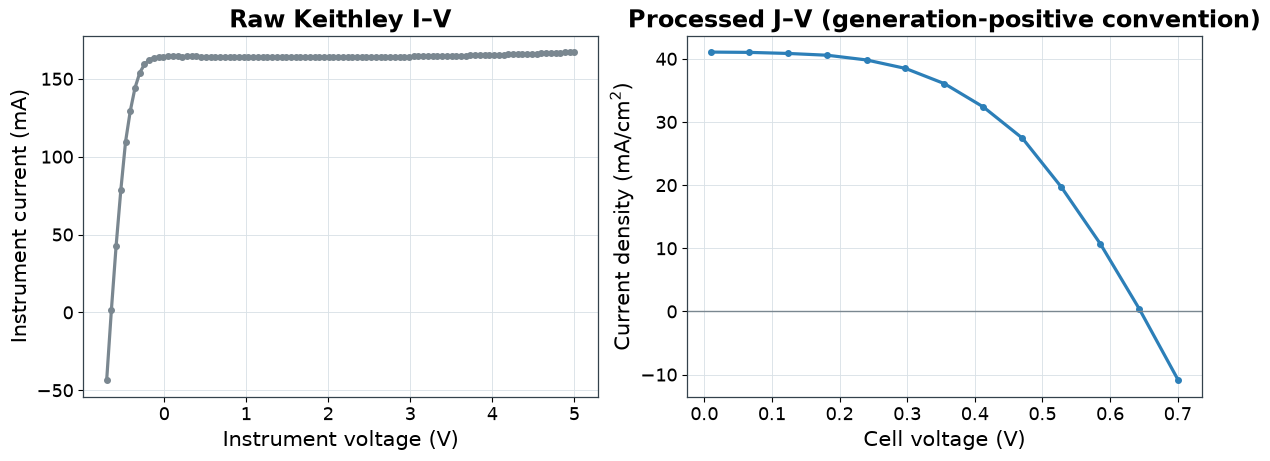

,sample,condition,J_mean_A_cm2,J_std_A_cm2,V_mean_V,V_std_V,n_points,V_at_I0_V
0,3,dark,0.000103,0.000001,0.000029,0.000004,100,0.228402
1,3,light,0.040459,0.000074,-0.000017,0.000004,100,0.643771


Note: The dark zero-current crossing is retained only as an instrument-offset diagnostic; it is not a physical dark-state Voc.


In [9]:
from scripts.prepare_keithley import parse_keithley

raw_path = Path("data/raw/keithley/light - iv -3.csv")
processed_path = Path("data/processed/light_iv_sample3.csv")
raw_voltage, raw_current = parse_keithley(raw_path)
processed = pd.read_csv(processed_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(raw_voltage, raw_current * 1e3, "o-", color=C_GRAY, ms=4)
axes[0].set(xlabel="Instrument voltage (V)", ylabel="Instrument current (mA)",
            title="Raw Keithley I–V")
axes[1].plot(processed["V"], processed["J"] * 1e3, "o-", color=C_BLUE, ms=4)
axes[1].axhline(0, color=C_GRAY, lw=1)
axes[1].set(xlabel="Cell voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Processed J–V (generation-positive convention)")
for ax in axes:
    ax.grid(True)
plt.show()

short_summary = pd.read_csv("data/processed/ishort_summary.csv")
voc_summary = pd.read_csv("data/processed/voc_summary.csv")
cell3_summary = short_summary.query("sample == 3").merge(
    voc_summary.query("sample == 3"), on=["sample", "condition"]
)
display(cell3_summary)
print(
    "Note: The dark zero-current crossing is retained only as an instrument-offset "
    "diagnostic; it is not a physical dark-state Voc."
)


## 12. First Use Synthetic J–V Data to Understand the Optimizer

Begin with `data/synthetic/iv.csv`, a dataset with known provenance. This separates the question “Does the code work?” from “Does the model fully represent the real device?” The orange markers are **synthetic reference data**, not experimental measurements. The optimizer adjusts the effective photogeneration scale factor and effective series resistance to reduce the sum of squared normalized residuals.


Starting the synthetic J–V calibration trace...


Converged after 54 evaluations and recorded 49 distinct states; final objective = 0.001343.


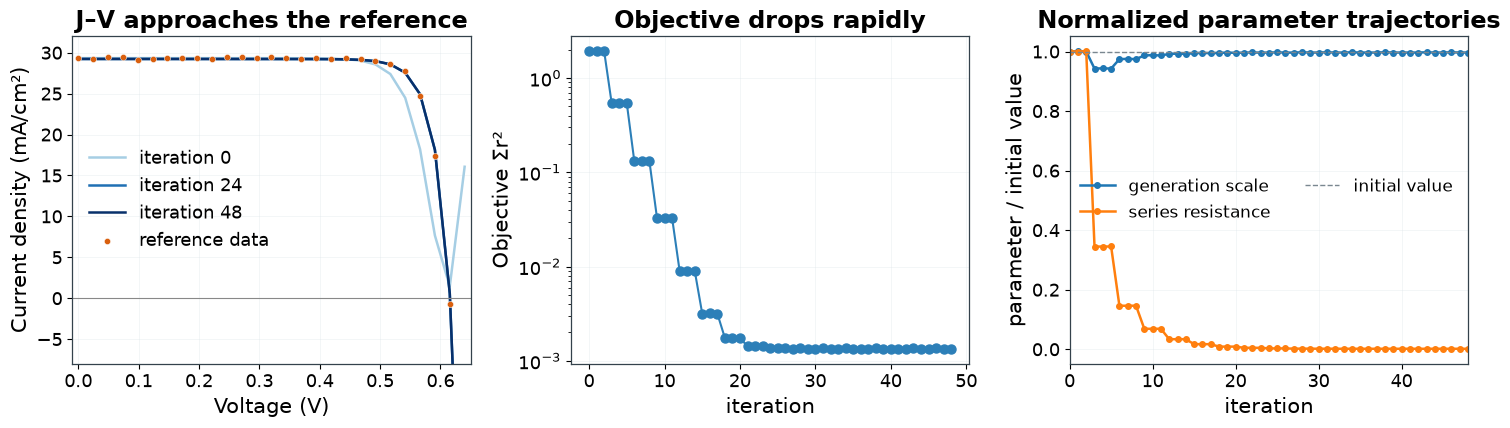

In [10]:
from calibration.fit import load_iv_csv, make_params
from calibration.trace import fit_with_trace, plot_optimization_trace

synthetic_voltage, synthetic_current = load_iv_csv("data/synthetic/iv.csv")
fit_parameters = make_params()
print("Starting the synthetic J–V calibration trace...")
trace_names, optimization_trace, synthetic_result = fit_with_trace(
    synthetic_voltage,
    synthetic_current,
    params=fit_parameters,
    max_nfev=60,
)
if not synthetic_result.success:
    raise RuntimeError(f"Synthetic calibration did not converge: {synthetic_result.message}")
print(
    f"Converged after {synthetic_result.nfev} evaluations and "
    f"recorded {len(optimization_trace)} distinct states; "
    f"final objective = {optimization_trace[-1]['chisq']:.4g}."
)
optimization_figure = plot_optimization_trace(
    trace_names, optimization_trace, synthetic_voltage, synthetic_current
)
display(optimization_figure)
plt.close(optimization_figure)


## 13. Joint Calibration of Cell #3: Complementary Observations Constrain Different Model Responses

The main example uses four types of historical observations from the same Cell #3:

| Observation | Primary information | Treatment in the objective function |
|---|---|---|
| Illuminated J–V | Photogenerated current, curve shape, and series loss | RMS block normalized by the current scale |
| Dark J–V | Cross-check on diode and leakage behavior; limited constraint on effective series resistance | Separate RMS block |
| Repeated illuminated $J_{sc}$ measurements | Near-zero-bias current density and repeatability | Mean with an uncertainty floor |
| Illuminated $V_{oc}$ | Zero-current condition | Constrains the modeled current at the measured $V_{oc}$ |

Each block is first nondimensionalized using an interpretable discrepancy scale and is then assigned a pedagogical weight. This prevents a dataset containing more sample points from automatically dominating the entire objective function. To keep the classroom runtime practical, the calibration objective evaluates terminal-circuit equation residuals at the measured voltage points. The final curves and RMSE values are then recomputed using the self-consistent terminal J–V solution. The residual-based objective and the self-consistent terminal solution agree for an exact fit; when systematic mismatch remains, the final curves and RMSE values should take priority in the interpretation.

This exercise fits only the effective photogeneration scale factor and effective series resistance. The dark curve is primarily a cross-check; it does not imply that lifetime, surface recombination velocity (SRV), or detailed diode physics has been identified. A zero-current voltage recorded under dark conditions is used only to diagnose instrument offset and must not be interpreted as a physical dark-state $V_{oc}$.


Cell #3: 13 illuminated J–V points and 15 dark J–V points
Independent illuminated Jsc check: 40.459 mA/cm^2
Independent illuminated Voc check: 0.6438 V


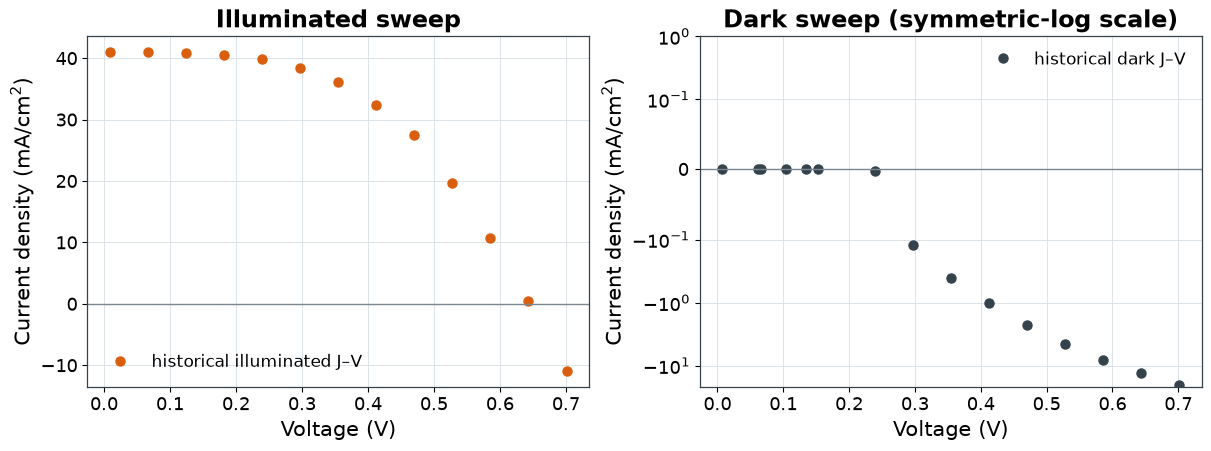

In [11]:
from calibration.fit import load_joint_data

joint_data = load_joint_data(3)
print(f"Cell #{joint_data.sample}: {len(joint_data.light_v)} illuminated J–V points and "
      f"{len(joint_data.dark_v)} dark J–V points")
print(f"Independent illuminated Jsc check: {joint_data.light_ishort['J_mean_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Independent illuminated Voc check: {joint_data.light_voc:.4f} V")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
axes[0].plot(joint_data.light_v, joint_data.light_j * 1e3, "o", color=C_ORANGE,
             label="historical illuminated J–V")
axes[0].axhline(0, color=C_GRAY, lw=1)
axes[0].set(xlabel="Voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Illuminated sweep")
axes[0].legend(frameon=False)
axes[1].plot(joint_data.dark_v, joint_data.dark_j * 1e3, "o", color=C_DARK,
             label="historical dark J–V")
axes[1].axhline(0, color=C_GRAY, lw=1)
axes[1].set_yscale("symlog", linthresh=0.1)
axes[1].set(xlabel="Voltage (V)", ylabel="Current density (mA/cm$^2$)",
            title="Dark sweep (symmetric-log scale)")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(True)
plt.show()


In [12]:
from calibration.fit import evaluate_joint, fit_joint, joint_block_score

print("Starting the Cell #3 joint calibration...")
joint_result = fit_joint(joint_data)
if not joint_result.success:
    raise RuntimeError(f"Joint calibration failed: {joint_result.message}")
joint_metrics = evaluate_joint(joint_result.params, joint_data)

block_score = joint_block_score(joint_result.chisqr, joint_data)
quality_limit = CALIBRATION["joint"].get("quality_warning_block_score", 4.0)
print(f"Normalized block score: {block_score:.3f} (1 = stated scales; 4 = twice-scale RMS)")
if block_score > quality_limit:
    print("WARNING: systematic model-data mismatch exceeds the teaching discrepancy scales.")
    print("Covariance values below are local sensitivity indicators, not validated parameter uncertainties.")

print("Fitted effective parameters and local covariance diagnostics:")
for name in ("photon_flux", "series_resistance"):
    parameter = joint_result.params[name]
    indicator = "unavailable" if parameter.stderr is None else f"{parameter.stderr:.3g}"
    print(f"  {name}: {parameter.value:.5g} (local covariance indicator: {indicator})")
print(f"Illuminated J–V RMSE: {joint_metrics['light_iv_rmse_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Dark J–V RMSE: {joint_metrics['dark_iv_rmse_A_cm2'] * 1e3:.3f} mA/cm^2")
print(f"Illuminated Voc error: {joint_metrics['light_voc_error_V'] * 1e3:+.2f} mV")


Starting the Cell #3 joint calibration...


Normalized block score: 280.801 (1 = stated scales; 4 = twice-scale RMS)
Covariance values below are local sensitivity indicators, not validated parameter uncertainties.
Fitted effective parameters and local covariance diagnostics:
  photon_flux: 1.5483 (local covariance indicator: 0.0197)
  series_resistance: 4.938 (local covariance indicator: 0.0577)
Illuminated J–V RMSE: 4.185 mA/cm^2
Dark J–V RMSE: 1.677 mA/cm^2
Illuminated Voc error: -16.48 mV


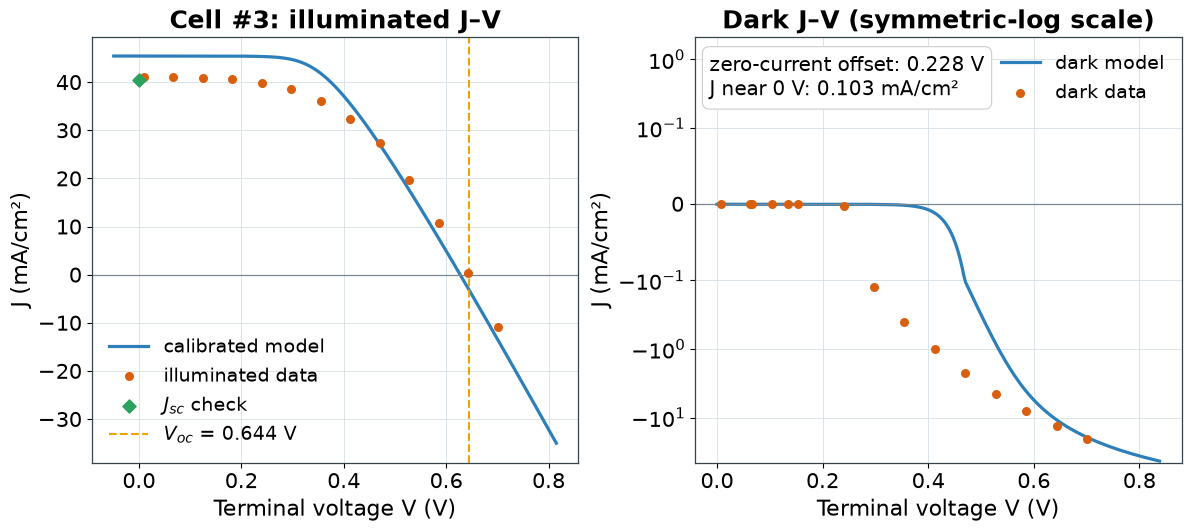

In [13]:
from calibration.report import joint_comparison_figure

joint_params = {**MODEL_PARAMS, **joint_result.params.valuesdict()}
joint_figure = joint_comparison_figure(joint_data, joint_params)
display(joint_figure)
plt.close(joint_figure)


## 14. A Good Fit Does Not Guarantee Trustworthy Parameters

Local covariance addresses the following question: given the current model, data, weighting, and optimum, can small changes in the parameters be distinguished? When relative uncertainties are large or parameters are strongly correlated, describe the fitted quantities as effective parameters and report that they are weakly constrained rather than drawing overly precise material conclusions. Even when relative uncertainties are small, systematic mismatch in the jointly fitted curves means that the result indicates only local numerical sensitivity; it does not establish model adequacy or the physical validity or uniqueness of the inferred parameter values. Adding more samples of the same observable is often less useful than adding observations with complementary physical information.


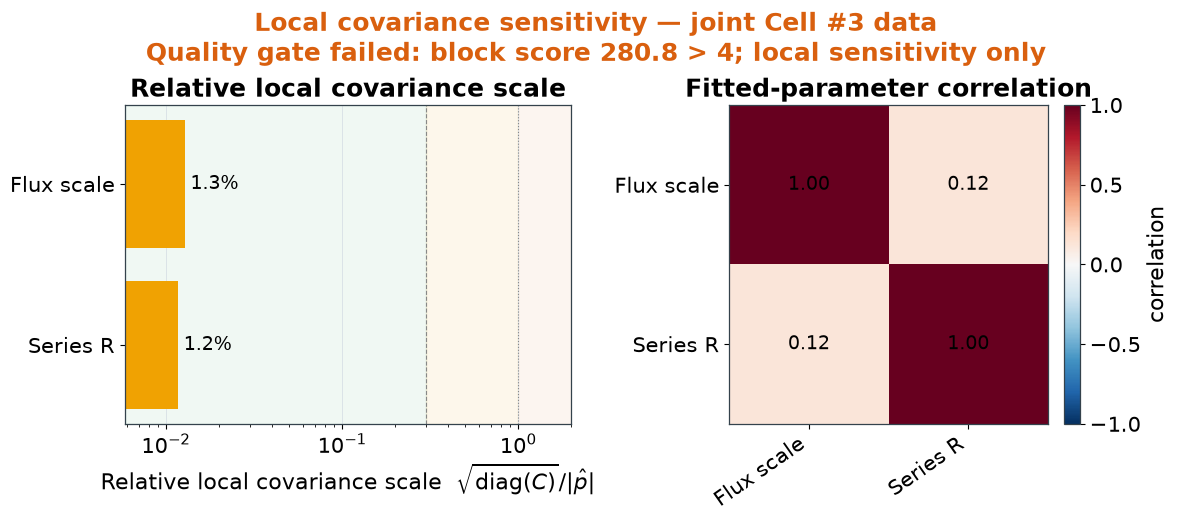

Local covariance sensitivity (quality gate failed):
  photon_flux: sqrt(diag(cov))/abs(fitted value) = 1.28% -> local numerical sensitivity only (quality gate failed)
  series_resistance: sqrt(diag(cov))/abs(fitted value) = 1.17% -> local numerical sensitivity only (quality gate failed)


In [14]:
from calibration.report import identifiability_figure, identifiability_summary

joint_names = getattr(joint_result, "var_names", None) or [
    name for name, parameter in joint_result.params.items() if parameter.vary
]
joint_covariance = getattr(joint_result, "covar", None)
quality_note = None if block_score <= quality_limit else (
    f"Quality gate failed: block score {block_score:.1f} > {quality_limit:g}; "
    "local sensitivity only"
)
identifiability = identifiability_figure(
    joint_result.params,
    covar=joint_covariance,
    var_names=joint_names,
    context="joint Cell #3 data",
    quality_note=quality_note,
)
display(identifiability)
plt.close(identifiability)
quality_adequate = block_score <= quality_limit
heading = ("Parameter identifiability" if quality_adequate else
           "Local covariance sensitivity (quality gate failed)")
print(f"{heading}:")
for line in identifiability_summary(
    joint_result.params, covar=joint_covariance, var_names=joint_names,
    quality_adequate=quality_adequate,
):
    print(f"  {line}")


## 15. Model Scope and Limitations

The scope of the model must be stated whenever its results are interpreted:

- **Structure:** One-dimensional abrupt p⁺-on-n junction; excludes surface texturing, front-grid shading, lateral current flow, and realistic process-derived graded doping profiles.
- **Transport and recombination:** Constant low-field mobilities and SRH and Auger recombination; surface recombination is represented by effective dead layers.
- **Optics:** A 16-bin AM1.5-like teaching input with Beer–Lambert absorption; a full thin-film interference model is not included.
- **Terminal model:** $R_s$ and $R_{sh}$ are area-normalized effective post-processing parameters and should not be interpreted directly as material constants of an individual layer.
- **Experiment:** The included Cell #3 and Cell #4 datasets are historical examples. Students should preserve their own raw data and record the active area and polarity. Efficiency should not be reported without an independent irradiance measurement.
- **Calibration:** A small residual shows only that the model approaches the selected observations; it does not prove that every internal parameter is physically correct or uniquely identifiable.


## 16. Summary and Next Steps

You have completed a reproducible closed-loop workflow:

1. Define a forward model using the p⁺-on-n structure together with the Poisson and drift–diffusion equations;
2. Use the Newton demonstration to understand nonlinear solution and interpret J–V behavior through internal profiles and the band diagram;
3. Establish clear boundaries among raw I–V data, processed J–V data, synthetic data, and historical measurements;
4. First use synthetic data to understand the optimizer, and then jointly calibrate the model using multiple experimental observations from Cell #3;
5. Use uncertainty and parameter correlation to determine which conclusions are supported by the data.

The next step is to add your measurements in a separate raw-data directory without overwriting the supplied historical files. Then rerun data processing and calibration using the recorded metadata, and explain in your report: **Which parameters changed? Which observations constrained them? What physics is still missing from the model?**
